## Importing Libraries

In this section, all the required libraries are imported. These libraries are used for data handling, data visualization, data preprocessing, training different regression models, and evaluating their performance.

In [86]:
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

## Reading the Dataset

In this section, the dataset is loaded into a Pandas DataFrame using `read_csv()`. This allows us to access and analyze the data for further preprocessing and model training.

In [87]:
# Reading the Dataset
fr = pd.read_csv(r"C:\D drive\desktop\python\ML Internship final project\Data_file - data_file.csv")

## Exploring the Dataset

In this section, the dataset is explored to understand its structure. We check the first few rows, dataset size, data types, summary statistics, missing values, and duplicate records.

In [88]:
# Exploring the Dataset
print(fr.head())
print(fr.shape)
print(fr.info())
print(fr.describe())
print(fr.isnull().sum())
print(fr.duplicated().sum())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  
(20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 2063

## Data Visualization

In this section, histograms are plotted for all the numerical features in the dataset. This helps us understand the distribution of each feature and identify any unusual patterns or outliers.

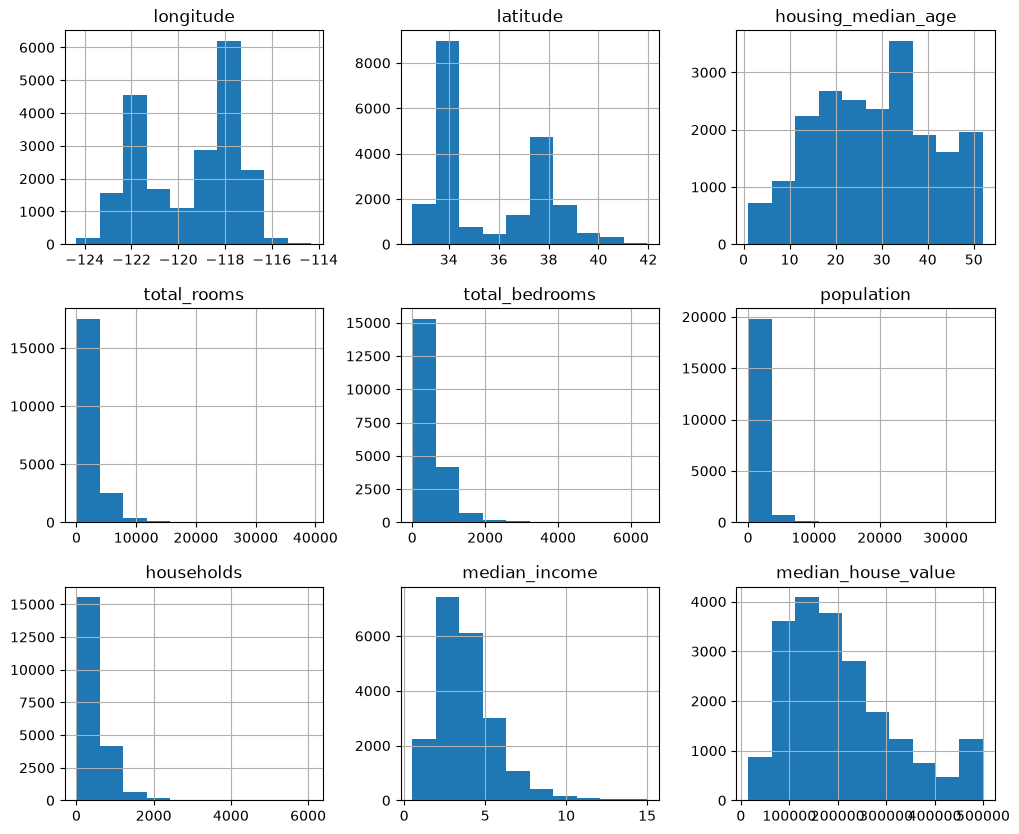

In [89]:
#Visualizing the Dataset
fr.hist(figsize=(12,10))
plt.show()

## Checking for Outliers

In this section, box plots are created for all the numerical columns to identify the presence of outliers in the dataset.

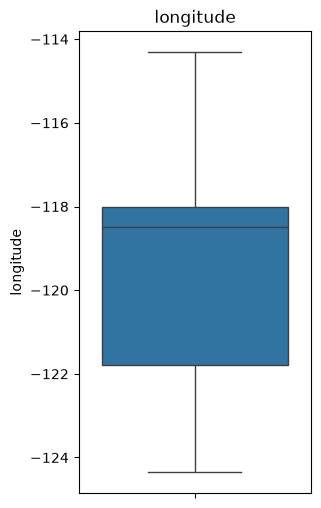

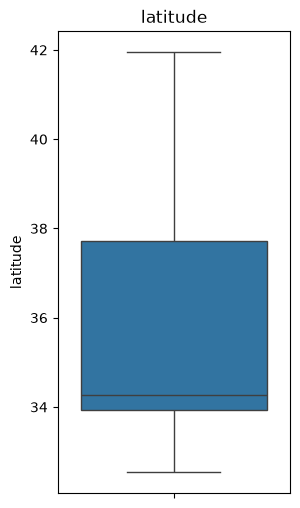

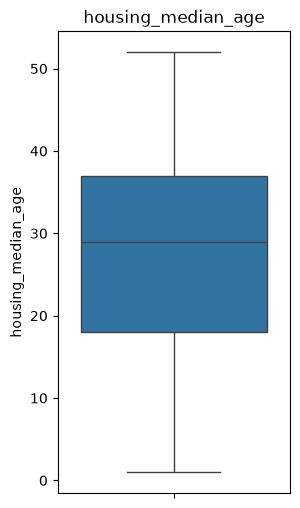

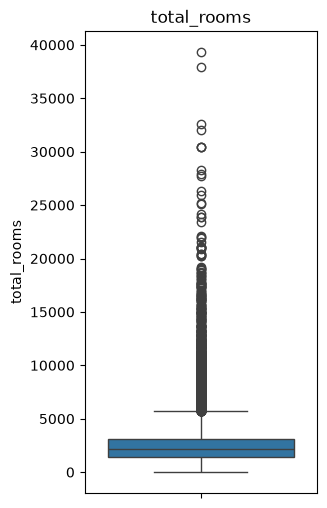

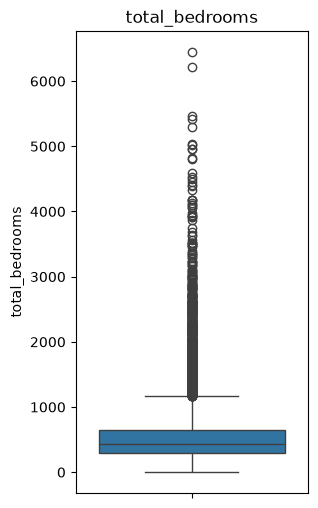

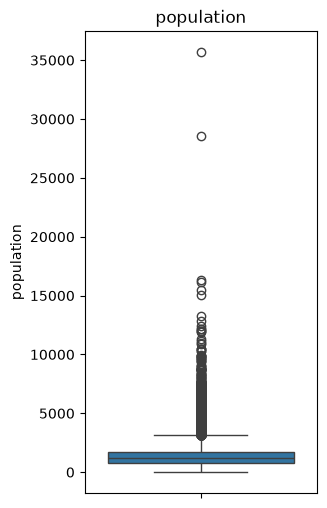

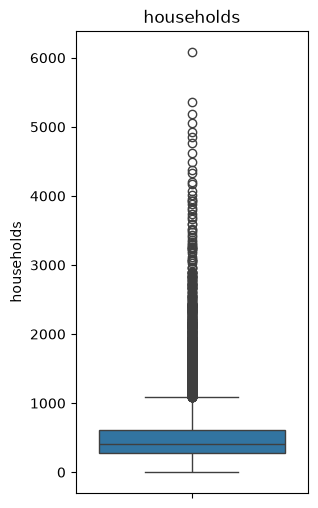

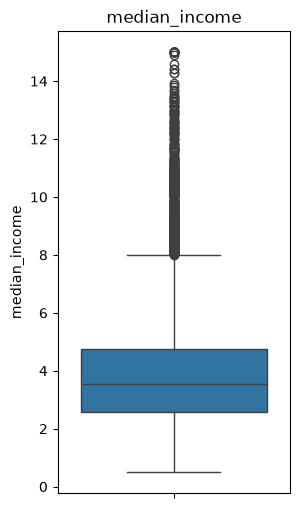

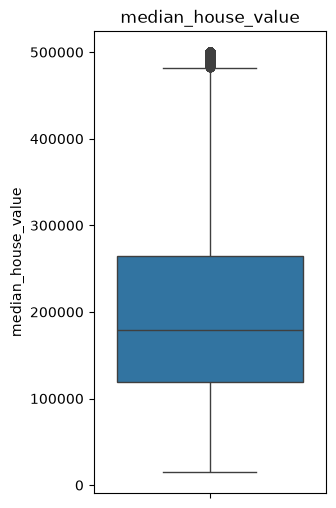

In [90]:
# Checking for Outliers
for col in fr.select_dtypes(include='number'):
    plt.figure(figsize=(3,6))
    sns.boxplot(y=fr[col])
    plt.title(col)
    plt.show()

## Correlation Analysis

In this section, a correlation heatmap and pair plot are used to understand the relationship between different features. The heatmap shows the correlation between numerical variables, while the pair plot helps visualize the distribution and relationship between features.

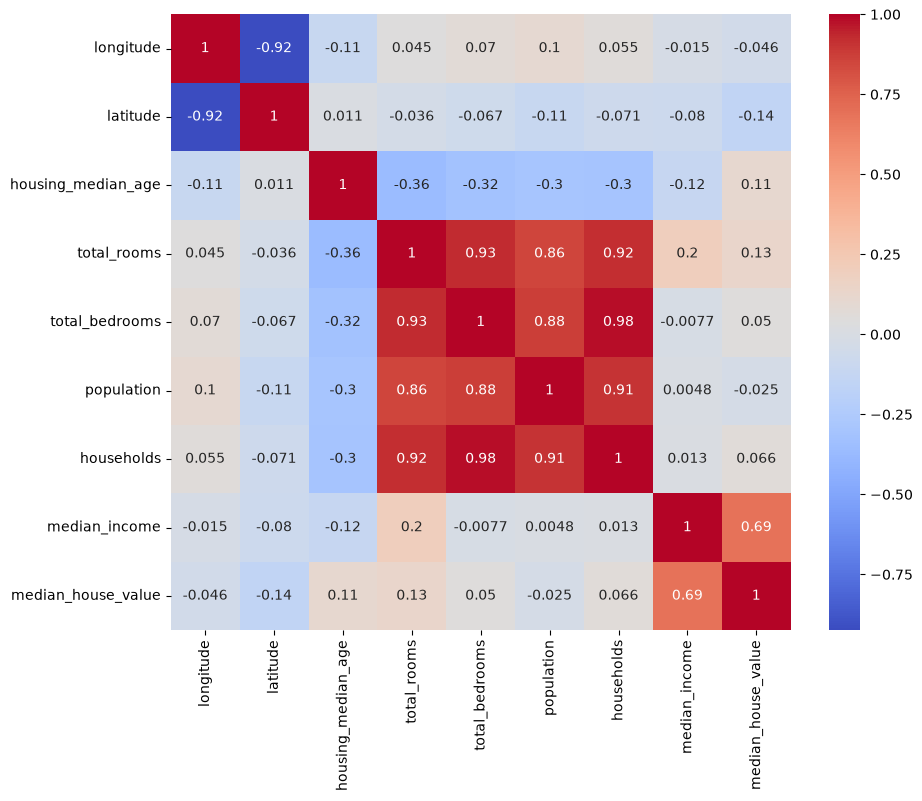

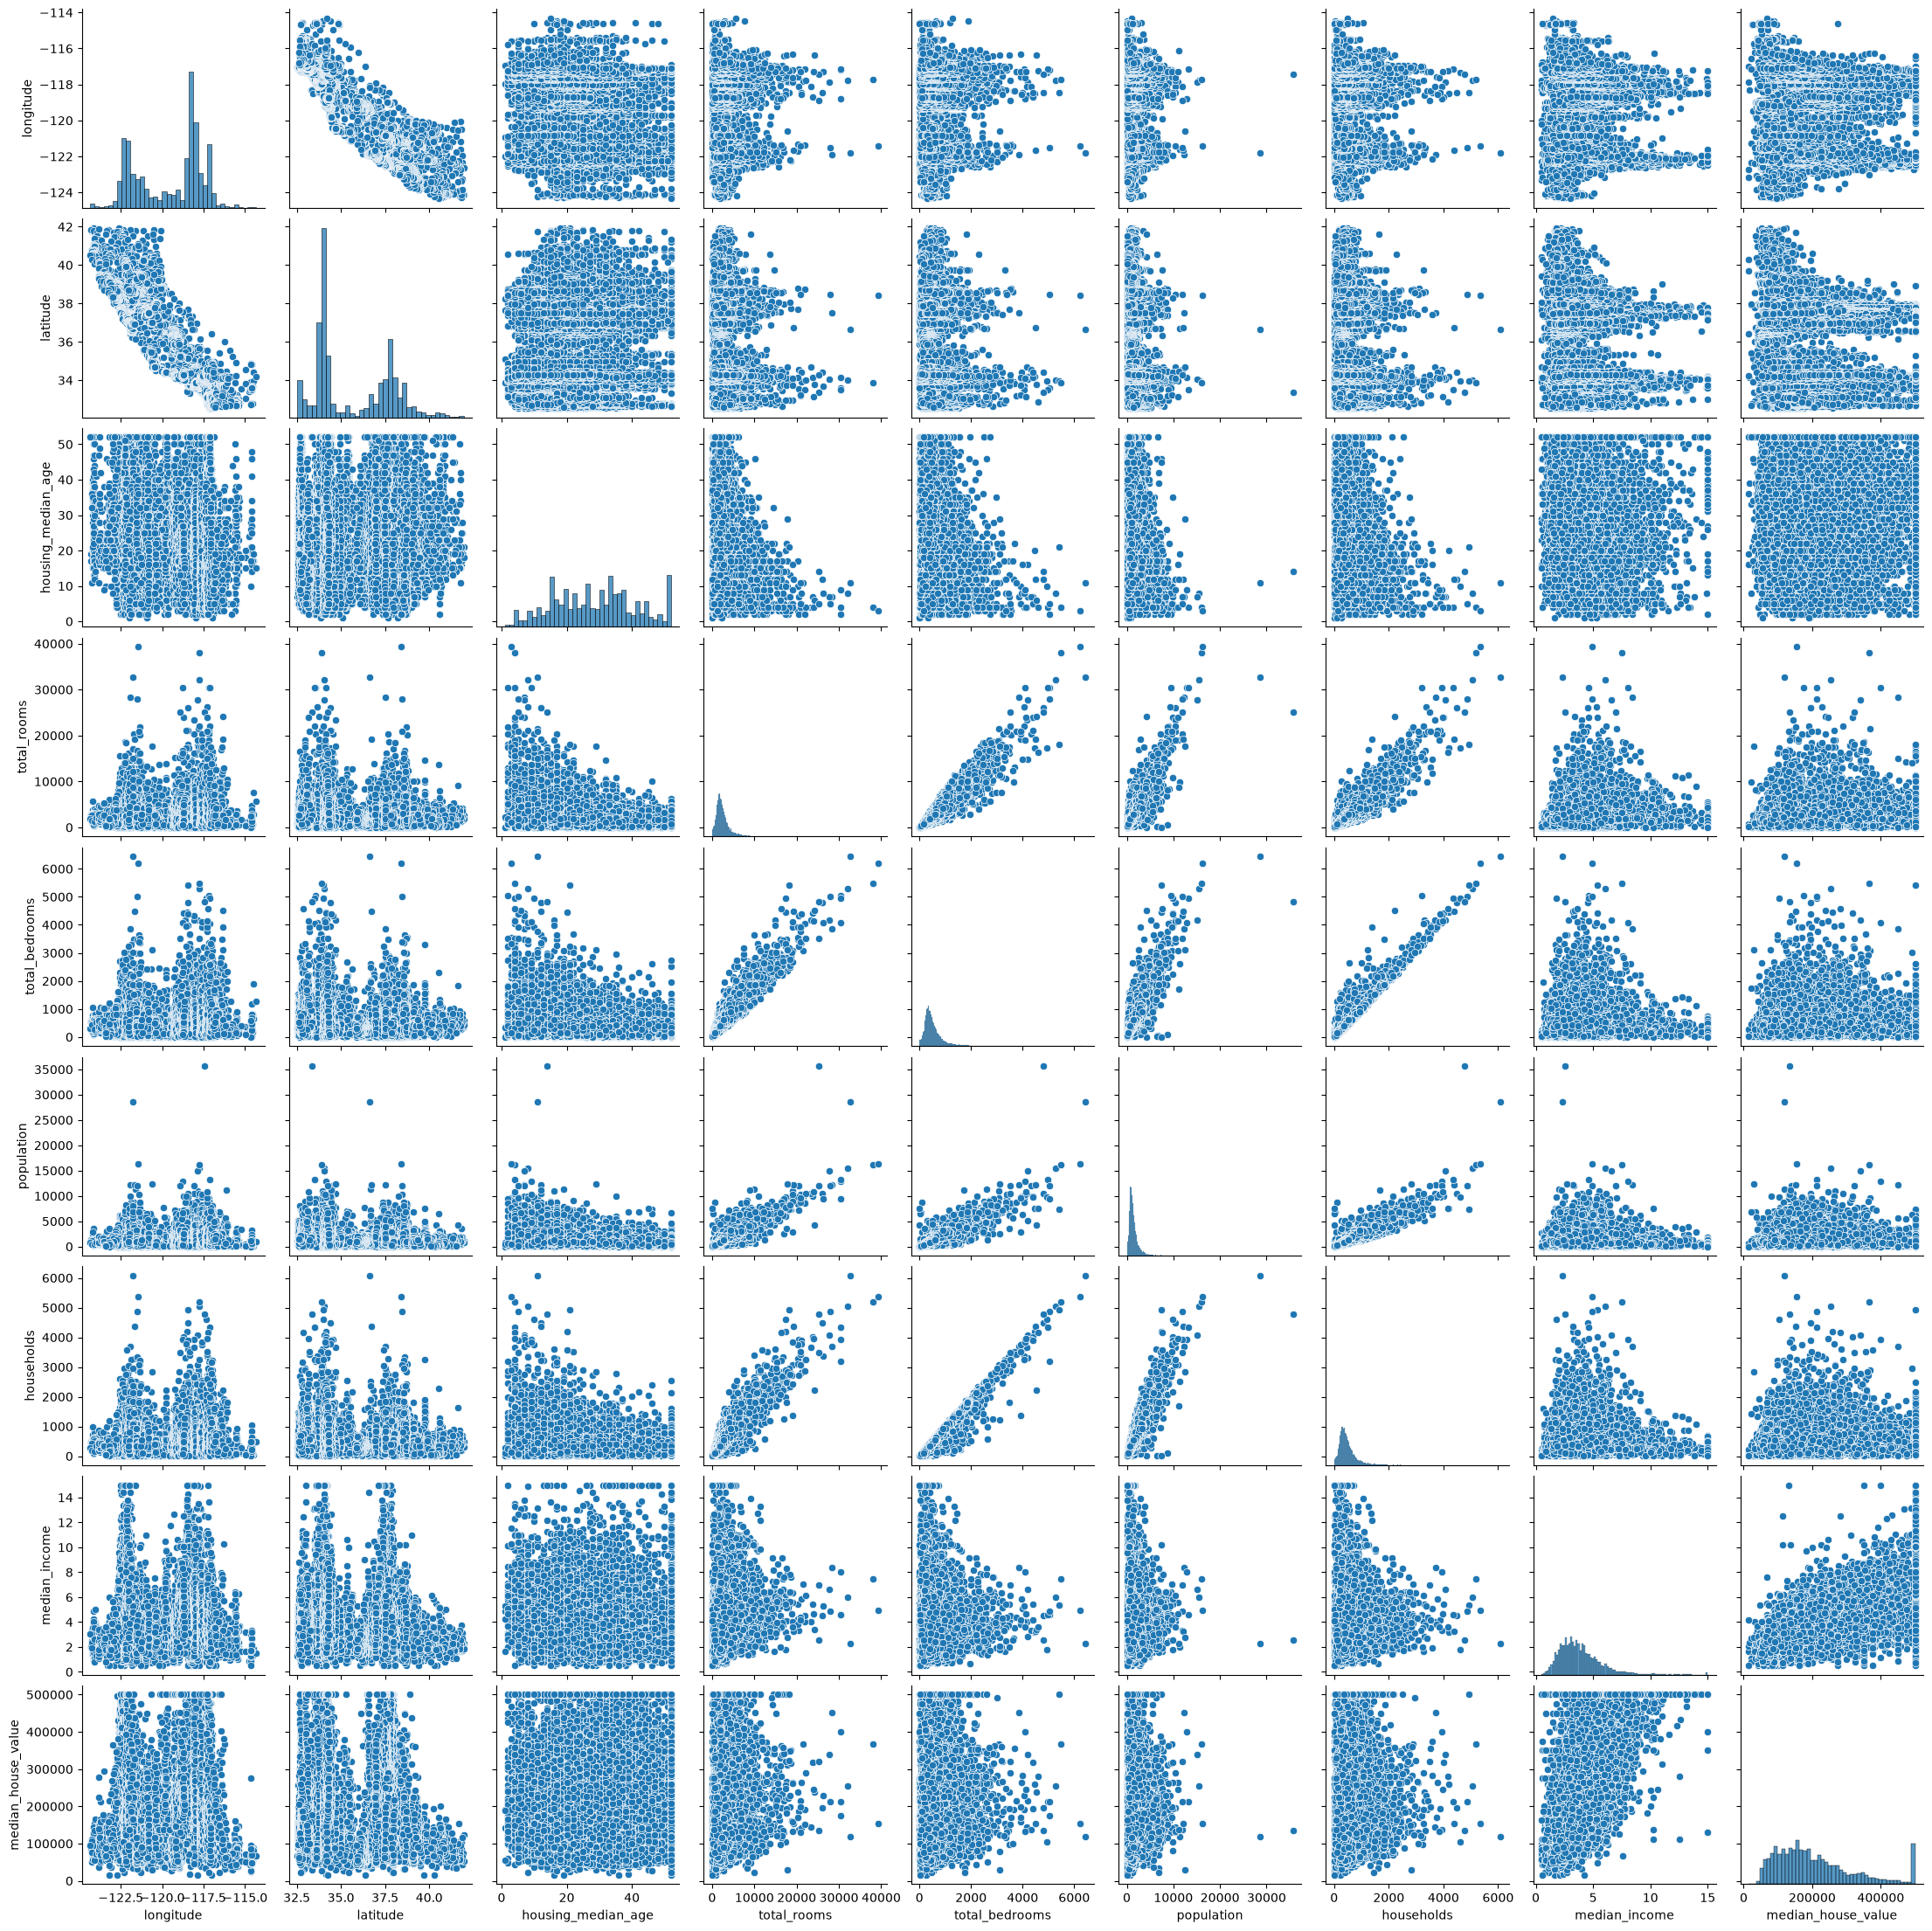

In [91]:
#Correlation Matrix & Pair plot
plt.figure(figsize=(10,8))

sns.heatmap(
    fr.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
sns.pairplot(fr)
plt.show()

## Handling Missing Values

In this section, the missing values in the `total_bedrooms` column are replaced with the median value. The median is used because it is less affected by outliers than the mean.

In [92]:
# Dealing with missing values
fr['total_bedrooms'] = fr['total_bedrooms'].fillna(fr['total_bedrooms'].median())
print(fr.total_bedrooms.isnull().sum())

0


## Handling Outliers

In this section, a copy of the dataset is created to preserve the original data. A logarithmic transformation is applied to selected columns to reduce skewness, and the IQR method is used to cap extreme values. Finally, box plots are generated again to check the dataset after outlier treatment.

20640
20640


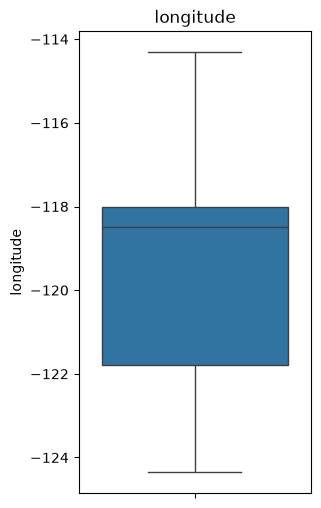

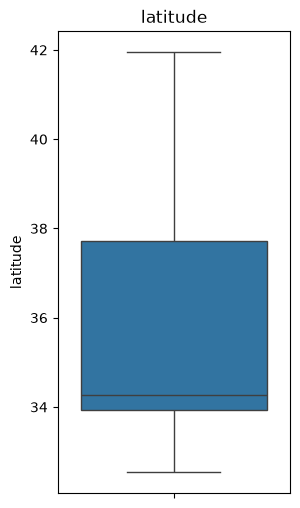

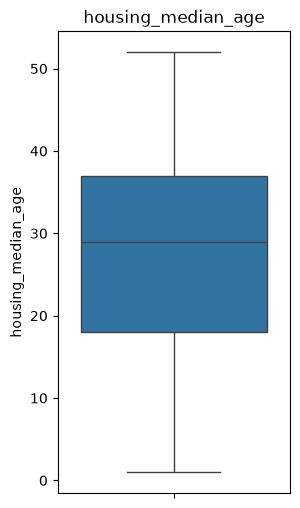

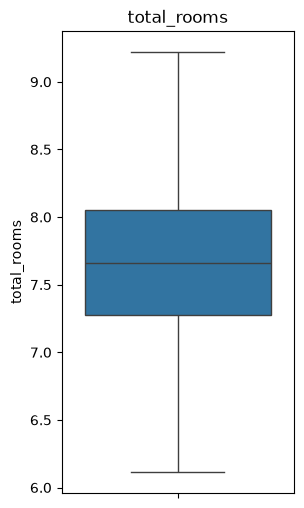

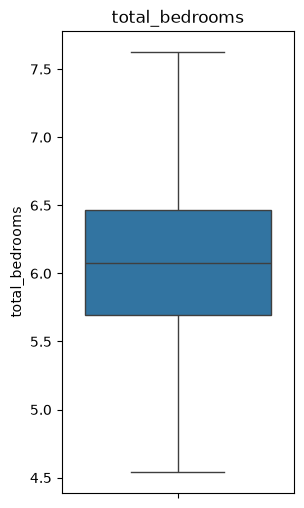

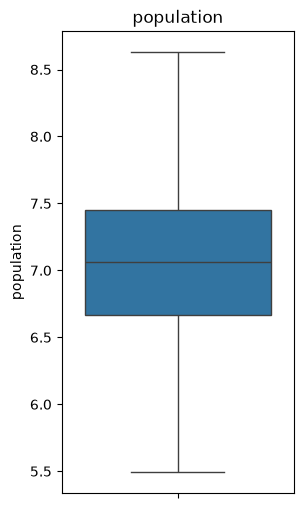

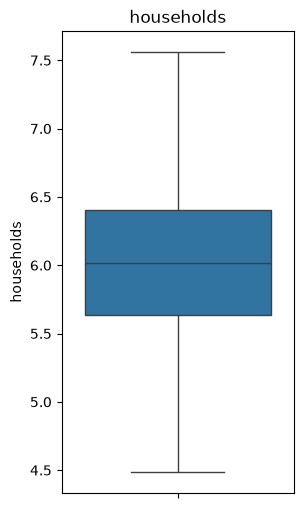

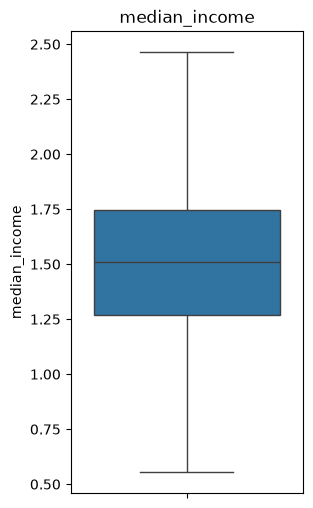

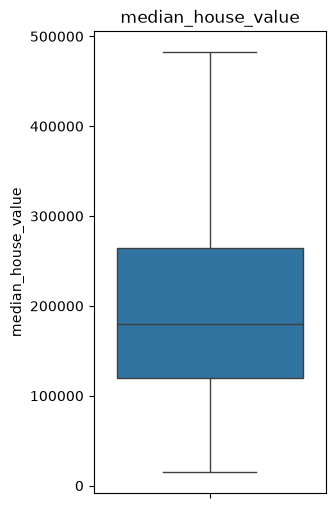

In [93]:
# Dealing with Outliers
fr_crul = fr.copy()
print(len(fr_crul))
num_cols = fr_crul.select_dtypes(include=np.number).columns.tolist()
columns = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
for col in columns:
    fr_crul[col] = np.log1p(fr_crul[col])

for col in num_cols:
    Q1 = fr_crul[col].quantile(0.25)
    Q3 = fr_crul[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    fr_crul[col] = np.clip(fr_crul[col], lower, upper)

print(len(fr_crul))
for col in num_cols:
    plt.figure(figsize=(3,6))
    sns.boxplot(y=fr_crul[col])
    plt.title(col)
    plt.show()

## Encoding Categorical Data

In this section, the categorical column `ocean_proximity` is converted into numerical columns using one-hot encoding. This allows the machine learning models to process the categorical data.

In [94]:
#Encoding a categorical column
fr_crul = pd.get_dummies(fr_crul,columns=["ocean_proximity"],dtype=int)
print(fr_crul.head())
print(fr.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41     6.781058        4.867534   
1    -122.22     37.86                  21     8.867850        7.009409   
2    -122.24     37.85                  52     7.291656        5.252273   
3    -122.25     37.85                  52     7.150701        5.463832   
4    -122.25     37.85                  52     7.395108        5.638355   

   population  households  median_income  median_house_value  \
0    5.777652    4.844187       2.232720            452600.0   
1    7.784057    7.037906       2.230165            358500.0   
2    6.208590    5.181784       2.111110            352100.0   
3    6.326149    5.393628       1.893579            341300.0   
4    6.338594    5.560682       1.578195            342200.0   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  \
0                          0                       0                       0   
1   

## Final Cleaned Dataset

In this section, the cleaned dataset is reviewed to verify that all preprocessing steps have been applied successfully and that the data is ready for model training.

In [95]:
#final dataset after cleaning
print(fr_crul.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  int64  
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  int64  
 10  ocean_proximity_INLAND      20640 non-null  int64  
 11  ocean_proximity_ISLAND      20640 non-null  int64  
 12  ocean_proximity_NEAR BAY    20640 non-null  int64  
 13  ocean_proximity_NEAR OCEAN  20640 non-null

## Feature Engineering

In this section, new features are created by combining existing columns. These engineered features help capture useful relationships in the data and may improve the performance of the regression models.

In [96]:
#Feature Engineering
fr_crul["total_rooms_per_households"] = fr_crul["total_rooms"] / fr_crul["households"]
fr_crul["total_bedrooms_per_rooms"] = fr_crul["total_bedrooms"] / fr_crul["total_rooms"]
fr_crul["population_per_households"] = fr_crul["population"] / fr_crul["households"]
fr_crul["income_latitude"] = fr_crul["median_income"] * fr_crul["latitude"]
fr_crul["income_longitude"] = fr_crul["median_income"] * fr_crul["longitude"]


## Feature Selection

In this section, the target column (`median_house_value`) is separated from the input features. The remaining columns are stored in `X`, while the target variable is stored in `Y` for model training.

In [97]:
# Feature selection
X = fr_crul.drop(["median_house_value"], axis=1)
Y = fr_crul['median_house_value']

## Splitting the Dataset

In this section, the dataset is split into training and testing sets. The training data is used to train the models, while the testing data is used to evaluate their performance.

In [98]:
# Spliting the data into traning and testing set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


## Checking Dataset Shapes

In this section, the shapes of the training and testing datasets are displayed to verify that the data has been split correctly.

In [99]:
# Shape of the training and testing datasets
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(16512, 18)
(4128, 18)
(16512,)
(4128,)


## Feature Scaling

In this section, the input features are standardized using `StandardScaler`. The scaler is fitted on the training data and then applied to both the training and testing datasets to ensure consistent scaling.

In [100]:
# feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Correlation Analysis After Feature Engineering

In this section, a correlation heatmap is generated after feature engineering. This helps us understand how the newly created features are related to each other and to the existing features, making it easier to identify strong positive or negative correlations.

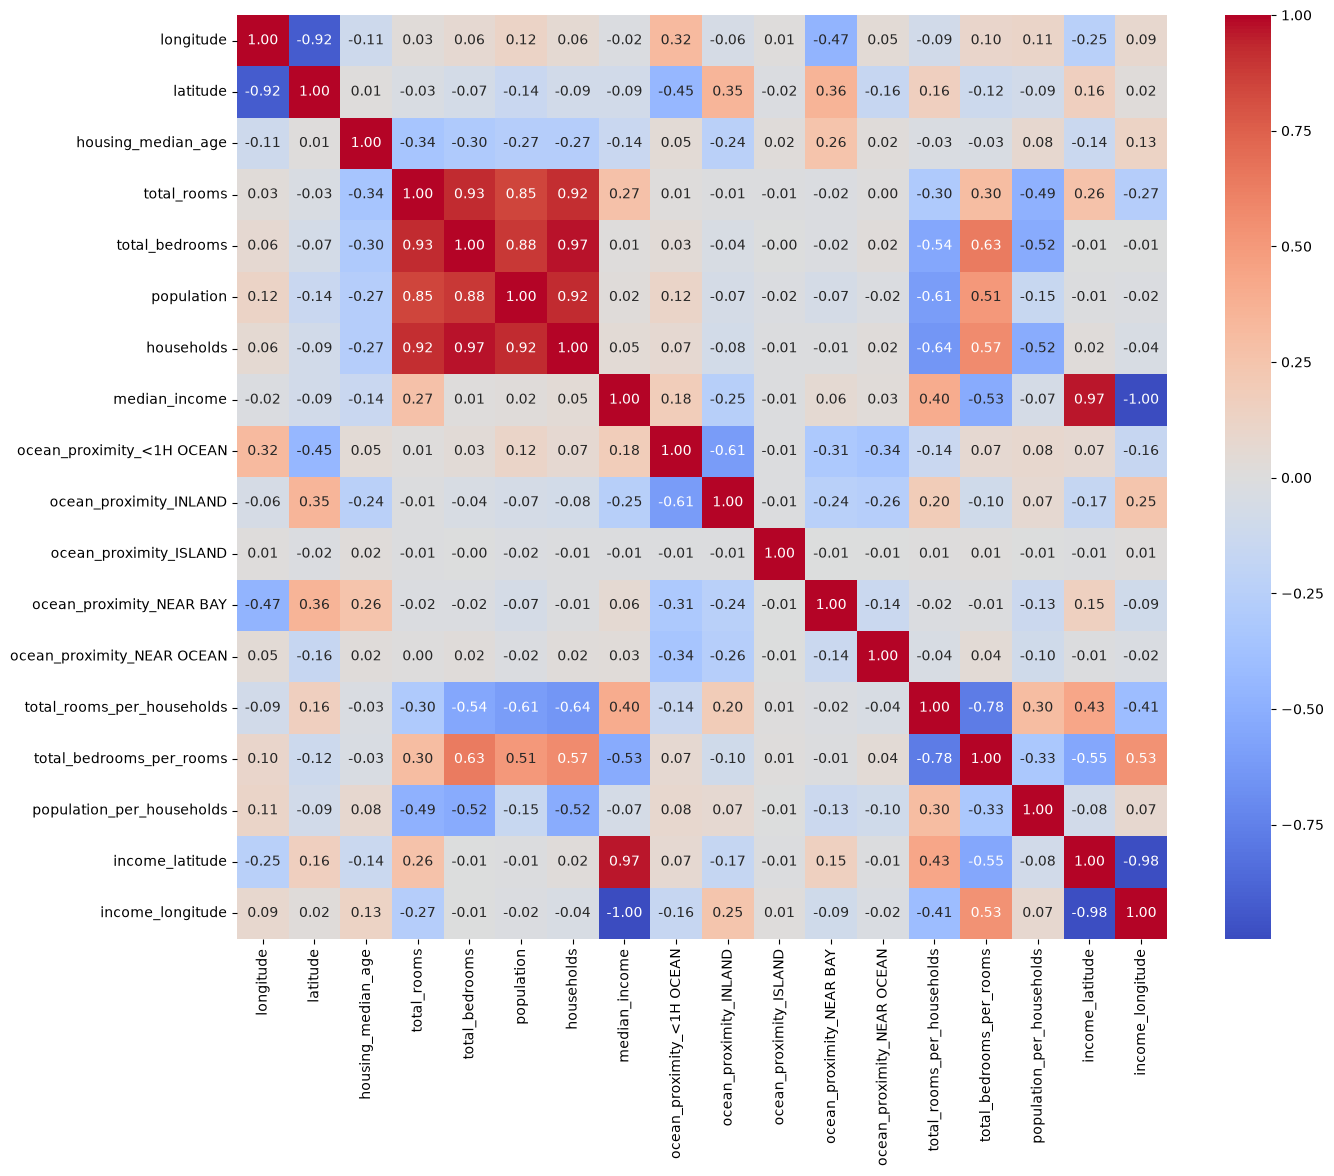

In [101]:
#Correlation Matrix & Pair plot after feature engineering
plt.figure(figsize=(15,12))

sns.heatmap(
    X.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",fmt=".2f"
)
#sns.pairplot(fr_crul)
plt.show()

## Model Training and Evaluation

In this section, multiple regression models are trained using the training dataset. Each model is evaluated on the testing dataset using **RMSE**, **MAE**, and **R² Score**. Finally, the model with the lowest RMSE is selected as the best-performing model.

In [102]:
# Initialize regression models
regressors = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "XGBoost": XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

best_model = None
best_rmse = float("inf")
model_results = {}

for name, model in regressors.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, Y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(Y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)

    model_results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    }

    print(
        f"{name} - RMSE: {rmse:.4f}, "
        f"MAE: {mae:.4f}, "
        f"R2 Score: {r2:.4f}"
    )

    # Lower RMSE is better
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model

print("\n--- Model Evaluation Results ---")

for name, metrics in model_results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

print(f"\nBest Model based on RMSE: {best_model.__class__.__name__}")
print(f"Best RMSE: {best_rmse:.4f}")


Training Linear Regression...
Linear Regression - RMSE: 67981.0739, MAE: 49765.1216, R2 Score: 0.6345

Training Decision Tree...
Decision Tree - RMSE: 69827.7710, MAE: 44419.2832, R2 Score: 0.6144

Training Random Forest...
Random Forest - RMSE: 50183.2649, MAE: 32764.2837, R2 Score: 0.8008

Training Gradient Boosting...
Gradient Boosting - RMSE: 52794.1829, MAE: 36391.0875, R2 Score: 0.7796

Training K-Nearest Neighbors...
K-Nearest Neighbors - RMSE: 57522.5770, MAE: 38974.5774, R2 Score: 0.7383

Training XGBoost...
XGBoost - RMSE: 47217.8317, MAE: 31199.7109, R2 Score: 0.8237

Training CatBoost...
CatBoost - RMSE: 44208.2190, MAE: 29470.6865, R2 Score: 0.8454

--- Model Evaluation Results ---

Linear Regression:
  RMSE: 67981.0739
  MAE: 49765.1216
  R2 Score: 0.6345

Decision Tree:
  RMSE: 69827.7710
  MAE: 44419.2832
  R2 Score: 0.6144

Random Forest:
  RMSE: 50183.2649
  MAE: 32764.2837
  R2 Score: 0.8008

Gradient Boosting:
  RMSE: 52794.1829
  MAE: 36391.0875
  R2 Score: 0.7796

## Final Performance Metrics

In this section, the final model is evaluated using **MAE**, **MSE**, **RMSE**, and **R² Score**. Additionally, the mean house price and the average prediction error (relative to the mean house price) are calculated to better understand the model's overall performance.

In [103]:
# predicting and evaluating
Y_pred = model.predict(X_test)
MAE = mean_absolute_error(Y_test, Y_pred)
MSE = mean_squared_error(Y_test, Y_pred)
R2 = r2_score(Y_test, Y_pred)
RMSE = root_mean_squared_error(Y_test, Y_pred)
mean_Y = np.mean(Y)
Avg_error = MAE/mean_Y

print("Mean Absolute Error:", MAE)
print("Mean Squared Error:", MSE)
print("R-squared:", R2)
print("Root Mean Squared Error:", RMSE)
print("Average Error:", Avg_error*100, "%")
print("Mean House Price:", mean_Y)

Mean Absolute Error: 29470.68650398476
Mean Squared Error: 1954366629.7785335
R-squared: 0.8454259398613003
Root Mean Squared Error: 44208.21902970684
Average Error: 14.307462492006598 %
Mean House Price: 205981.2249757752


## Feature Importance

In this section, the importance of each feature is calculated using the best-performing model. The features are then sorted in descending order to identify which ones have the greatest influence on predicting house prices.

In [104]:
# coefficient of each features
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.feature_importances_
})

coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
0,longitude,14.626650
9,ocean_proximity_INLAND,14.180723
1,latitude,13.852126
7,median_income,13.222276
15,population_per_households,12.983101
17,income_longitude,11.995499
2,housing_median_age,5.792204
16,income_latitude,3.909161
13,total_rooms_per_households,2.656346
14,total_bedrooms_per_rooms,1.590172


## Actual vs Predicted Values

In this section, a scatter plot is created to compare the actual house prices with the predicted values. The red diagonal line represents perfect predictions, and points closer to this line indicate better model performance.

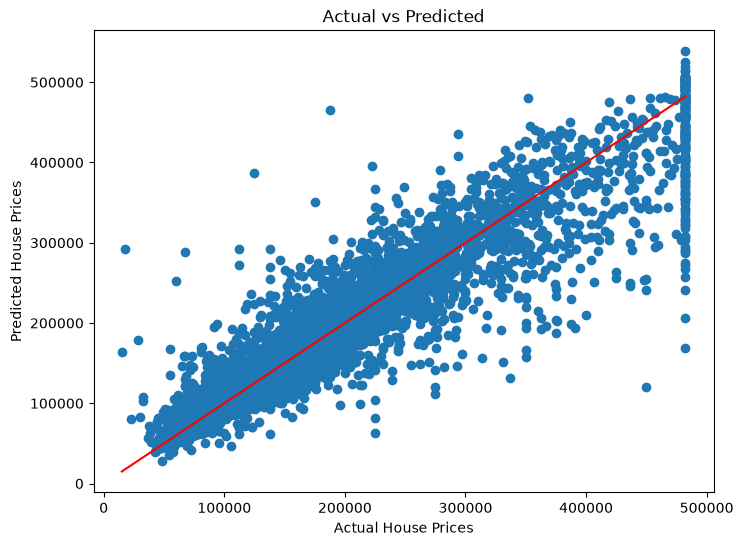

In [105]:
# Visualization of actual vs predicted sales
plt.figure(figsize=(8,6))

plt.scatter(Y_test, Y_pred)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color='red'
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted")

plt.show()

## Residual Analysis

In this section, the residuals (difference between actual and predicted values) are analyzed. A residual plot is used to check for any patterns in the prediction errors, while a histogram shows the distribution of the residuals.

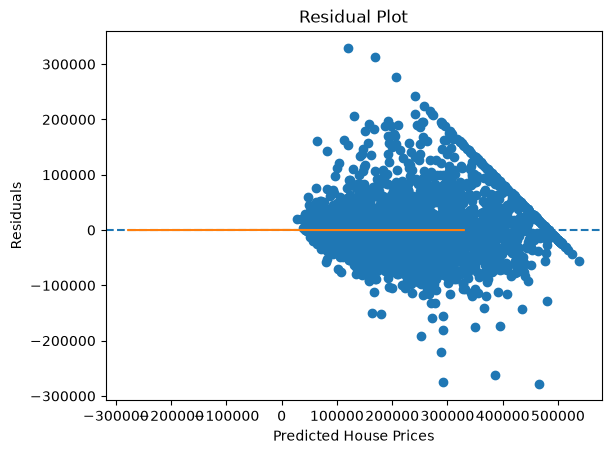

In [106]:
# residual analysis
residuals = Y_test - Y_pred

plt.scatter(Y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
sns.histplot(residuals, kde=True)
plt.show()